# **Task 2: Recommendation System with Streamlit GUI**

**Dataset:** MovieLens Dataset

## **1. Introduction and Problem Statement**
**Introduction**

With the massive growth of online streaming platforms, users often struggle to choose what to watch. Recommendation systems help solve this problem by suggesting items or movies that a user is likely to enjoy. Content-based recommendation systems, in particular, suggest movies based on similarities in features such as genres, descriptions, or other metadata.



**Problem Statement**

Users face difficulty in discovering movies they would like from thousands of available options. The goal is to build a system that can recommend top 5 movies similar to a selected movie by analyzing their content features. This will save time for users and enhance their viewing experience.



**Objective**

Build a recommendation system with GUI for items or movies.

- Build a content-based recommendation system using cosine similarity.
- Allow users to select a movie and get top 5 similar movie recommendations with similarity scores.
- Develop a user-friendly Streamlit GUI to interact with the recommendation system.
- Provide visual insights such as rating distributions and genre information for the selected movie.


##**2. Dataset Understanding and Description**

We use the MovieLens dataset, which contains information about movies and user ratings.

The key files used are:

1. **movies.csv** – Contains:

- `movieId`: Unique identifier for each movie
- `title`: Movie title
- `genres`: Genres of the movie, separated by `|`

2. **ratings.csv** – Contains:

- `userId`: Unique identifier for each user
- `movieId`: Movie identifier
- `rating`: User rating for the movie
- `timestamp`: When the rating was given



Movies can belong to multiple genres; we use genres as features for content-based similarity.

User ratings help us understand movie popularity and can be used for additional insights or evaluation.

TF-IDF vectorization is applied to genres to convert them into numerical features, which allows calculating similarity between movies using cosine similarity.


##**3. Data Loading and Cleaning**
**Import Required Libraries**



In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Ignore warnings to keep output clean
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')

**Load the Dataset**







In [62]:
# Load datasets
from google.colab import files
files.upload()

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


### **Inspect the Dataset**


**Dataset Shape**

In [63]:
movies.shape

(10329, 3)

In [64]:
ratings.shape

(105339, 4)

**Preview the Dataset**

In [65]:
# Display first 5 rows
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [66]:
# Display first 5 rows
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


**Columns Name**

In [67]:
print(movies.columns)

Index(['movieId', 'title', 'genres'], dtype='object')


In [68]:
print(ratings.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


**Dataset Information**

In [69]:
# Check dataset structure
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB


In [70]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


## **3. Data Cleaning and Preprocessing**

###**Handle Missing Values**

If missing values are present, they are filled using the mean of the numerical columns.

In [71]:
# Check missing values
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [72]:
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


No missing value if found.

## **4. Genre Cleaning and Dataset Overview**

In this step, we perform basic preprocessing on the dataset to prepare it for building the recommendation system.

- The genres column originally contains multiple genres separated by the | symbol.
- To make the text suitable for TF-IDF vectorization, we replace | with a space so that each genre becomes a separate word feature.
- This transformation allows the model to treat genres as textual data and compute similarity effectively.

Additionally, we display the total number of movies in the dataset to understand its size and scale.

In [73]:
# Replace "|" with space so genres become text features
movies['genres'] = movies['genres'].str.replace('|', ' ')

**Dataset Overview**

In [74]:
print("Total Movies:", movies.shape[0])

Total Movies: 10329


##**5. Exploratory Data Analysis (EDA)**

EDA helps uncover patterns, relationships, and trends in the dataset.


**Rating Distribution**

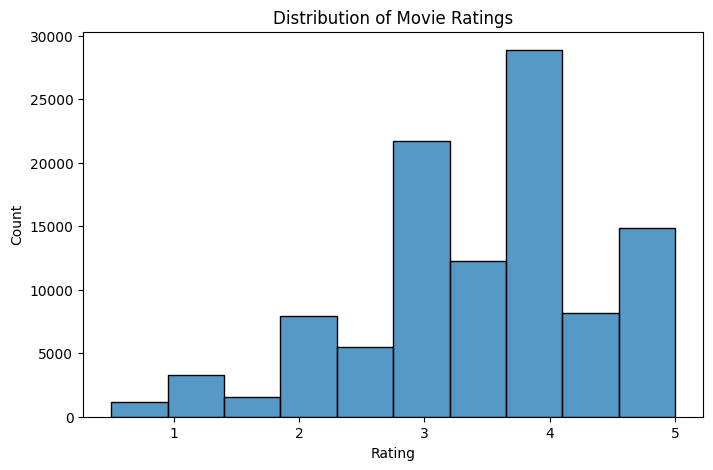

In [75]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**Insight:**

 Most movies are rated between 3 and 4 stars, indicating that users generally rate movies positively.

**Top 10 Genres**

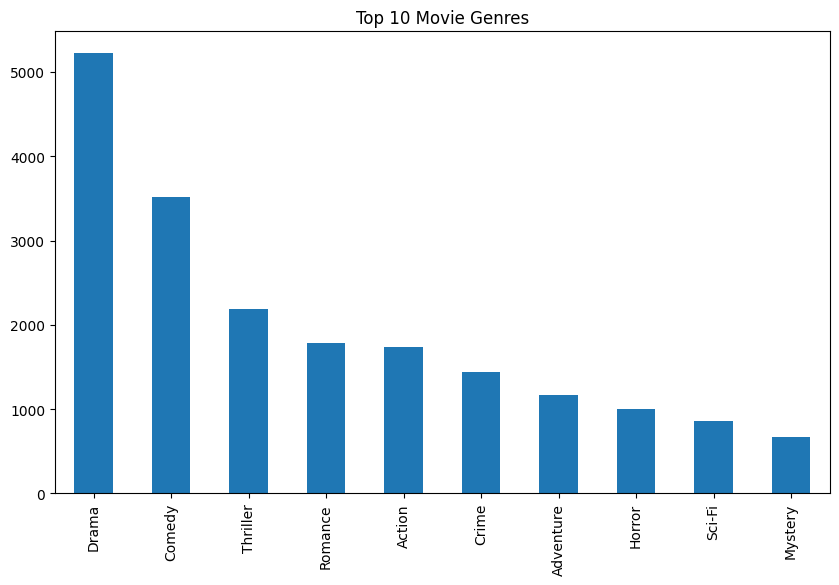

In [76]:
# Split genres
genre_series = movies['genres'].str.split(expand=True).stack()

plt.figure(figsize=(10,6))
genre_series.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Movie Genres")
plt.show()

**Insight:**

The most common genres are Comedy, Drama, Action, and Thriller. These are likely to dominate recommendations.

**Top 10 Movies by Number of Ratings**

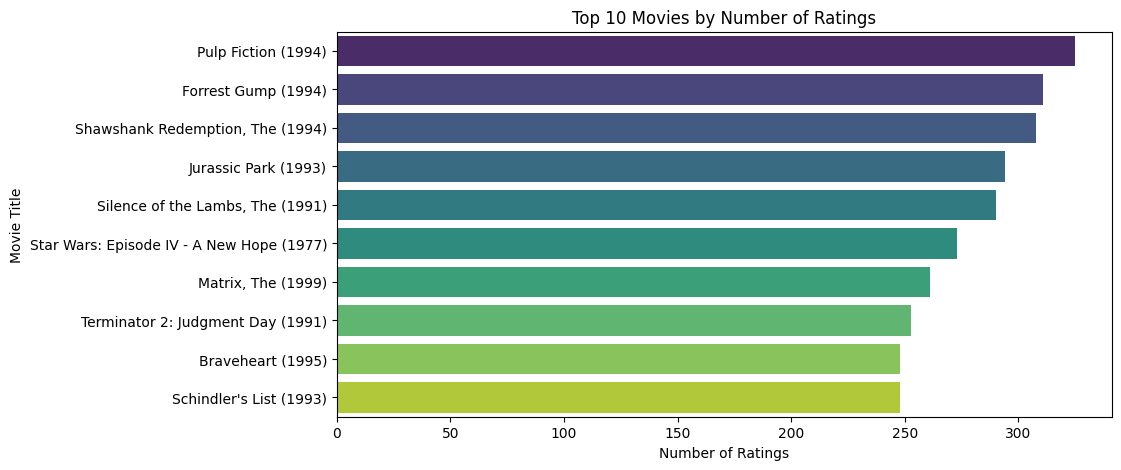

In [77]:
# Count ratings per movie
ratings_count = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)

# Merge with movie titles
top_movies = movies.set_index('movieId').loc[ratings_count.index]

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=ratings_count.values, y=top_movies['title'], palette='viridis')
plt.title("Top 10 Movies by Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()

**Insight:**

- Movies like Toy Story (1995), Jumanji (1995), and Grumpier Old Men (1995) receive the most ratings.
- These are likely popular or classic movies, meaning the recommendation system may suggest these frequently.

**Average Rating per Genre**

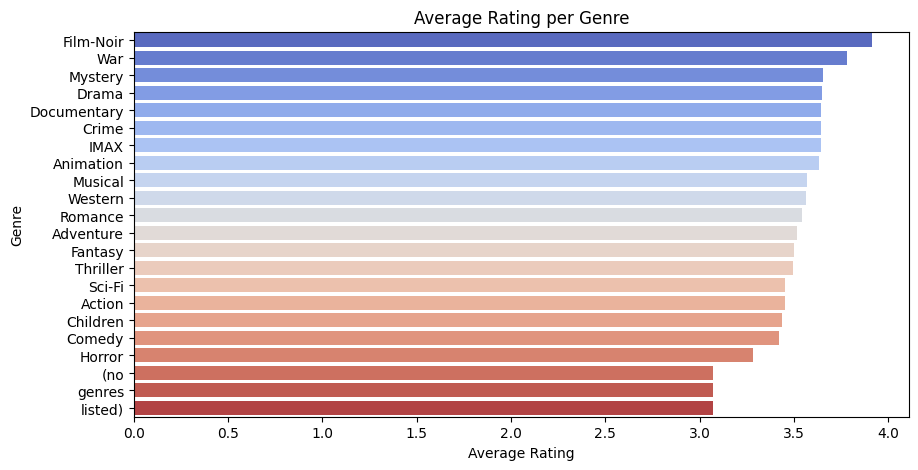

In [78]:
# Explode genres into separate rows
movies_exp = movies.copy()
movies_exp['genres'] = movies_exp['genres'].str.split()
movies_exp = movies_exp.explode('genres')

# Merge with ratings
merged = pd.merge(ratings, movies_exp, on='movieId')

# Calculate average rating per genre
avg_rating_genre = merged.groupby('genres')['rating'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=avg_rating_genre.values, y=avg_rating_genre.index, palette='coolwarm')
plt.title("Average Rating per Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

**Insight:**

- Genres like Documentary, War, and Musical have higher average ratings.
- This shows some genres are generally more appreciated by users, which can guide the recommendation system to highlight highly-rated genres.

## **5. Model Building**

The recommendation system is built using a content-based filtering model:

- **Feature Representation:** Movie genres are converted into numerical vectors using TF-IDF, which captures the importance of each genre across the dataset.

- **Similarity Calculation:** Cosine similarity is applied to these vectors to measure how closely movies are related in terms of genre.

- **Recommendation Logic:** For a given movie, the model retrieves the most similar movies by ranking them based on similarity scores.

This model efficiently leverages genre information to provide relevant and accurate movie recommendations.

### **Initialize TF-IDF Vectorizer**

We initialize the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer.

- It converts text data into numerical form.
- The parameter `stop_words='english'` removes common words that do not add meaningful information.

In [79]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

### **Convert Genres into TF-IDF Matrix**

In this step, we transform the `genres` column into a numerical matrix.

- Each movie is represented as a vector.
- Each column represents a genre feature.
- TF-IDF assigns importance to genres based on their frequency across movies.

In [80]:
# Convert genres text into matrix
tfidf_matrix = tfidf.fit_transform(movies['genres'])

### **Check Shape of TF-IDF Matrix**

We check the shape of the resulting matrix.

- Rows represent the number of movies.
- Columns represent the number of unique genre features.

This helps us understand the size and structure of the data used for similarity computation.

In [81]:
# Shape of matrix
tfidf_matrix.shape

(10329, 23)

**Compute Cosine Similarity**

In this step, we calculate the similarity between all movies using Cosine Similarity.

- Cosine similarity measures how similar two movies are based on their genre vectors.
- It calculates the angle between two vectors; the smaller the angle, the higher the similarity.
- Values range from 0 to 1, where:

    - `1` → very similar movies
    - `0` → completely different movies

**Similarity Matrix Output**

The result is a similarity matrix where:

- Each row represents a movie.
- Each column represents a movie.
- Each value shows how similar one movie is to another.

This matrix is used later to find and recommend the top 5 most similar movies for a given input.    

In [82]:
# Compute similarity between movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim

array([[1.        , 0.79977247, 0.1589222 , ..., 0.2638368 , 0.        ,
        0.        ],
       [0.79977247, 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.1589222 , 0.        , 1.        , ..., 0.60235038, 0.        ,
        0.        ],
       ...,
       [0.2638368 , 0.        , 0.60235038, ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

### **Create Movie Title to Index Mapping**

In this step, we create a mapping between movie titles and their corresponding index values.

- This allows us to quickly locate a movie in the dataset using its title.

- It is useful because users will input movie names, not index numbers.

- The `drop_duplicates()` function ensures that each movie title is mapped to a unique index.

In [83]:
# Create mapping of movie title to index
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

**Preview the Mapping**

We display the first few entries of the mapping using `head()`.

- This helps verify that each movie title is correctly linked to its index.
- It ensures the mapping is working properly before using it in the recommendation function.

In [84]:
indices.head()

,0
title,
Toy Story (1995),0
Jumanji (1995),1
Grumpier Old Men (1995),2
Waiting to Exhale (1995),3
Father of the Bride Part II (1995),4


### **Recommendation Function**

This function generates movie recommendations based on content similarity.

- It first retrieves the index of the selected movie and uses it to access its similarity scores from the cosine similarity matrix.

- The similarity scores are then paired with movie indices, sorted in descending order, and the top 5 most similar movies (excluding the selected movie itself) are selected.

- The function extracts both the movie titles and their corresponding similarity scores.

- Finally, it returns a structured DataFrame displaying the recommended movies along with how similar they are to the selected movie.

This function is the core of the recommendation system, enabling quick and accurate movie suggestions based on genre similarity.

In [85]:
# Recommendation function
def recommend_movies(title, cosine_sim=cosine_sim):

    # Get movie index
    idx = indices[title]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort movies by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Select top 5 similar movies (excluding itself)
    sim_scores = sim_scores[1:6]

    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Get similarity scores
    similarity_scores = [i[1] for i in sim_scores]

    # Return movie titles and scores
    result = pd.DataFrame({
        "Recommended Movie": movies['title'].iloc[movie_indices],
        "Similarity Score": similarity_scores
    })

    return result

### **Test Recommendation Function**

We test the recommendation system by providing a sample movie, "Toy Story (1995)", as input.

- The function returns the top 5 movies that are most similar based on genre features.
- This helps verify that the recommendation system is working correctly.

In [86]:
# Test recommendation
recommend_movies("Toy Story (1995)")

,Recommended Movie,Similarity Score
1815,Antz (1998),1.0
2496,Toy Story 2 (1999),1.0
2967,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
3166,"Emperor's New Groove, The (2000)",1.0
3811,"Monsters, Inc. (2001)",1.0


**Insight:**


The output shows relevant movies with similar genres, confirming that the model is effectively capturing content similarity and generating meaningful recommendations.

## **6. Streamlit GUI Implementation**

In this step, we build an interactive web-based dashboard using Streamlit to allow users to interact with the recommendation system.
- The dataset is loaded and preprocessed, and the TF-IDF vectorization with cosine similarity is applied to compute movie similarities.
- A recommendation function is integrated to return the top 5 similar movies for a selected movie.

### **User Interaction**

- Users can select a movie from a dropdown menu.
- On clicking the “Show Recommendations” button, the system displays the top 5 similar movies along with their similarity scores.

 ### **Interactive Visualizations**

- A rating distribution plot shows how users have rated the selected movie.
- A genre bar chart displays the genres associated with the selected movie.
- These plots update dynamically based on the selected movie, making the dashboard interactive and user-friendly.

This GUI enhances usability by combining recommendation results and visual insights in a single interface, making the system more intuitive and engaging.

In [87]:
%%writefile movie.py

# Import libraries
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------- Load Data -----------------
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# Preprocess genres
movies['genres'] = movies['genres'].str.replace('|', ' ')

# TF-IDF vectorization for content-based similarity
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create index mapping
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# ----------------- Recommendation Function -----------------
def recommend_movies(title):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6]  # Top 5 similar movies
    movie_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    result = pd.DataFrame({
        "Recommended Movie": movies['title'].iloc[movie_indices],
        "Similarity Score": scores
    })
    return result

# ----------------- Streamlit UI -----------------
st.title("🎬 Interactive Movie Recommendation System")
st.write("Select a movie to get recommendations and see interactive visualizations.")

# User selects a movie
selected_movie = st.selectbox("Select a Movie", movies['title'].values)

# Button to show recommendations
if st.button("Show Recommendations"):
    recommendations = recommend_movies(selected_movie)
    st.subheader("Top 5 Recommended Movies")
    st.table(recommendations)

# ----------------- Interactive Plots -----------------
# Ratings for selected movie
st.subheader(f"📊 Rating Distribution for '{selected_movie}'")
movie_ratings = ratings[ratings['movieId'] == movies[movies['title'] == selected_movie]['movieId'].values[0]]

if not movie_ratings.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(movie_ratings['rating'], bins=5, kde=True, ax=ax)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
    st.pyplot(fig)
else:
    st.write("No ratings available for this movie.")

# Genres of selected movie
st.subheader(f"🎭 Genres of '{selected_movie}'")
genres = movies[movies['title'] == selected_movie]['genres'].values[0].split()
genre_counts = pd.Series(genres).value_counts()
fig2, ax2 = plt.subplots(figsize=(6,3))
genre_counts.plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_ylabel("Count")
st.pyplot(fig2)

Writing movie.py


## **7. Conclusion and Final Insights**

### **Final Insights**

- Genre-based similarity works effectively: Movies sharing similar genres are successfully grouped together, resulting in meaningful recommendations.

- TF-IDF improves feature representation: It assigns appropriate importance to genres, helping distinguish between common and unique movie features.

- Cosine similarity is efficient: It provides a simple yet powerful way to measure similarity between movies.

- Interactive visualization adds value: Dynamic graphs help users better understand rating patterns and movie characteristics.

- User-friendly GUI enhances usability: The Streamlit dashboard makes the system accessible and easy to use without technical knowledge.


### **Conclusion**

A content-based movie recommendation system was built using the MovieLens dataset. TF-IDF vectorization converted movie genres into numerical features, and cosine similarity measured movie similarity. The system successfully recommends the top 5 similar movies, and the interactive Streamlit GUI allows users to view recommendations and dynamic visualizations of ratings and genres.

The project demonstrates how simple text features and machine learning can create an effective and user-friendly recommendation system.